# Import libraries

In [1]:
from experiment_common_code import ExperimentResult, plot_metrics_by_group, plot_confusion_matrix, show_plots, ExperimentResult
from utils import LANGUAGES, MODEL_NAMES, LABEL_MAP, REVERSE_LABEL_MAP, get_language_pair_permutations, get_all_language_merged_strings
from icecream import ic
import pandas as pd
from pandas import DataFrame

import torch as t

from typing import Literal, Any

device: Literal["cuda", "cpu"] = "cuda" if t.cuda.is_available() else "cpu"

# Experiment 1

Load important variables

In [ ]:
from experiment_1 import run_experiment_1

model_names: list[str] = MODEL_NAMES
languages: list[str] = LANGUAGES
probe_type: str = "mm"
num_layers: int | None = None

custom = False
if custom:
    model_names = ["olmo_model"]
    languages = ["en"]
    probe_type = "mm"
    print(f"Using custom configuration")

ic(custom, model_names, languages, probe_type)

ic| custom: False
    model_names: ['olmo_model', 'tiny_aya_global']
    languages: ['en', 'es', 'jp', 'nl']
    probe_type: 'mm'


(False, ['olmo_model', 'tiny_aya_global'], ['en', 'es', 'jp', 'nl'], 'mm')

Run experiment 1

In [ ]:
limited_layers = False
if limited_layers:
    num_layers = 3

force_probe_creation: bool = False

save_results: bool = True

ic(limited_layers, force_probe_creation, save_results)

run_experiment_1(languages, "standard", "control", probe_type, model_names, force_probe_creation, num_layers=num_layers, save_results=save_results)

In [ ]:
example_exp_result: ExperimentResult = ExperimentResult.get_from_file(
                        1, "en", "standard", probe_type, "olmo_model"
                    )
print(example_exp_result.metrics["test"].keys())
for layer_num in range(example_exp_result.get_num_layers()):
    print(f"Layer {layer_num}")
    # overlapping_idxs: dict[str, set[int]] = example_exp_result.overlapping_idxs["test"]
    overlapping_idxs: dict[str, set[int]] = example_exp_result.get_metric("test", "cummulative_overlapping_idxs", layer_num)
    for key, value in overlapping_idxs.items():
        real_value = key[5]
        prediciton = key[-1]
        if real_value != prediciton:
            # print(key)
            # print(value)
            print(f"{key}→{len(value)}")
    
    

Make some plots

Created line request:
["exp_result: [1, 'en', 'standard', 'mm', 'olmo_model']", 'split: test', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [1, 'en', 'control', 'mm', 'olmo_model']", 'split: test', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [1, 'es', 'standard', 'mm', 'olmo_model']", 'split: test', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [1, 'es', 'control', 'mm', 'olmo_model']", 'split: test', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [1, 'jp', 'standard', 'mm', 'olmo_model']", 'split: test', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [1, 'jp', 'control', 'mm', 'olmo_model']", 'split: test', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [1, 'nl', 'standard', 'mm', 'olmo_model']", 'split: test', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [1, 'nl', 'control', 'mm', 'olmo_model']", 'split: test', 'class_id: ',

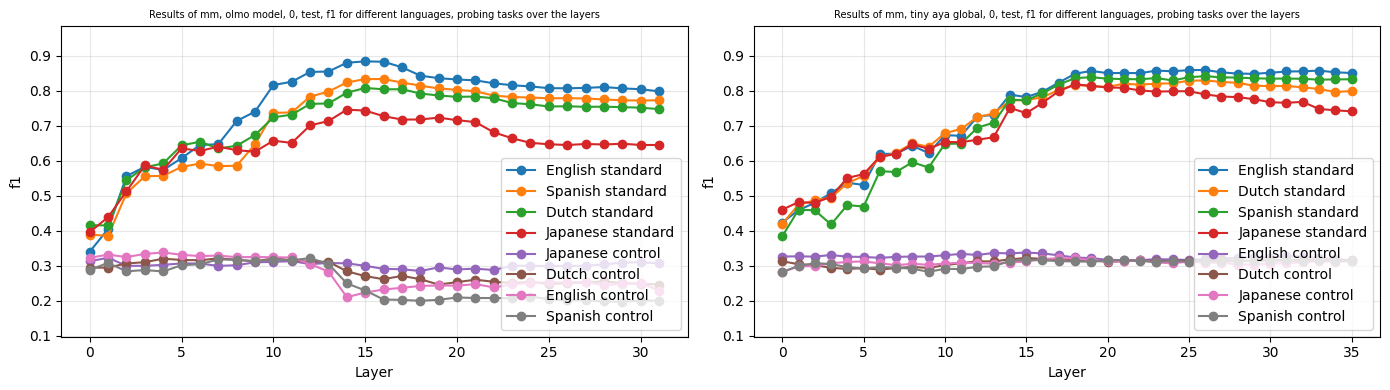

In [4]:
# Get list of plots showing some arbitrary metric
metric = "f1"
# metric = "per_class_precision"

show_plots(1, 
           model_names, 
           ["test"], 
           languages, 
           ["standard", "control"], 
           metric=metric,
           legend_position="lower right",
           probe_type=probe_type
           )

In [ ]:
metric = "previous_layer_overlapping_idx_amounts"

show_plots(1, 
           model_names, 
           ["test"], 
           languages, 
           ["standard"], 
           metric=metric,
           separate_chars_within_plot=["class_name"],
           legend_position="upper right"
           )

In [ ]:
# Get list of plots showing accuracy for just the test set
metric = "f1"
show_plots(1, 
           model_names, 
           ["test"], 
           languages, 
           ["standard", "control"], 
           metric=metric)

In [ ]:
# for model_name in model_names:
#     for split in ["test"]:
#         for language in languages:
#             for probing_task in probing_tasks:
#                 exp_result: ExperimentResult = ExperimentResult.get_from_file(
#                     1, language, probing_task, probe_type, model_name
#                 )

#                 for layer_num in range(exp_result.get_num_layers()):
#                     plot_confusion_matrix(exp_result, split, layer_num)

for probing_task in ["standard", "control"]:
    exp_result: ExperimentResult = ExperimentResult.get_from_file(1, "en", probing_task, probe_type, "olmo_model")

    for layer_num in range(exp_result.get_num_layers()):
        plot_confusion_matrix(exp_result, "test", layer_num)

# Experiment 2

Load important variables

In [12]:
from experiment_2 import run_experiment_2

model_names: list[str] = MODEL_NAMES
language_pairs: list[tuple[str, str]] = get_language_pair_permutations(LANGUAGES)
num_refits = 3
iterations_per_refit = 1000
probe_type: str = "lr"

custom = False
if custom:
    model_names = ["olmo_model"]
    language_pairs = [("en", "en"), ("es", "es"), ("jp", "jp")]
    probe_type = "lr"
    num_refits = 2
    print(f"Using custom configuration")

language_pairs_as_strings: list[str] = get_all_language_merged_strings(language_pairs)

ic(custom, model_names, language_pairs, num_refits, iterations_per_refit, language_pairs_as_strings, probe_type)

ic| custom: False
    model_names: ['olmo_model', 'tiny_aya_global']
    language_pairs: [('en', 'es'),
                     ('en', 'jp'),
                     ('en', 'nl'),
                     ('es', 'en'),
                     ('es', 'jp'),
                     ('es', 'nl'),
                     ('jp', 'en'),
                     ('jp', 'es'),
                     ('jp', 'nl'),
                     ('nl', 'en'),
                     ('nl', 'es'),
                     ('nl', 'jp')]
    num_refits: 3
    iterations_per_refit: 1000
    language_pairs_as_strings: ['en→es', 'en→jp', 'en→nl', 'es→en', 'es→jp', 'es→nl', 'jp→en', 'jp→es', 'jp→nl', 'nl→en', 'nl→es', 'nl→jp']
    probe_type: 'lr'


(False,
 ['olmo_model', 'tiny_aya_global'],
 [('en', 'es'),
  ('en', 'jp'),
  ('en', 'nl'),
  ('es', 'en'),
  ('es', 'jp'),
  ('es', 'nl'),
  ('jp', 'en'),
  ('jp', 'es'),
  ('jp', 'nl'),
  ('nl', 'en'),
  ('nl', 'es'),
  ('nl', 'jp')],
 3,
 1000,
 ['en→es',
  'en→jp',
  'en→nl',
  'es→en',
  'es→jp',
  'es→nl',
  'jp→en',
  'jp→es',
  'jp→nl',
  'nl→en',
  'nl→es',
  'nl→jp'],
 'lr')

Run experiment 2

In [ ]:
num_layers: int | None = None

limited_layers = False
if limited_layers:
    num_layers = 5

force_probe_creation: bool = False
force_refit_probe_creation: bool = True

save_results: bool = True

ic(limited_layers, num_layers, force_probe_creation, force_refit_probe_creation, save_results)

run_experiment_2(language_pairs, 
                 "standard", 
                 "control", 
                 probe_type, 
                 model_names, 
                 num_refits=num_refits,
                 iterations_per_refit=iterations_per_refit,
                 force_probe_creation=force_probe_creation, 
                 force_refit_probe_creation=force_refit_probe_creation,
                 num_layers=num_layers, 
                 save_results=save_results,
                 )

Make some plots

In [ ]:
extra_iter_nums = [0, 1000, 2000]
show_plots(2, 
           model_names, 
           ["test_a", "test_b"],
           language_pairs_as_strings, 
           ["standard"], 
           list(extra_iter_nums), 
           metric="f1",
           separate_chars_within_plot=["split"],
           probe_type=probe_type
           )

Created line request:
["exp_result: [2, 'en→es', 'standard', 'mm', 'olmo_model']", 'split: test_a', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→es', 'control', 'mm', 'olmo_model']", 'split: test_a', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'standard', 'mm', 'olmo_model']", 'split: test_a', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'control', 'mm', 'olmo_model']", 'split: test_a', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'standard', 'mm', 'olmo_model']", 'split: test_a', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'control', 'mm', 'olmo_model']", 'split: test_a', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'standard', 'mm', 'olmo_model']", 'split: test_a', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'control', 'mm', 'olmo_

FileNotFoundError: [Errno 2] No such file or directory: './data/experiment_results/experiment_2/en→es,standard,mm,olmo_model,1_extra_iters.pkl'

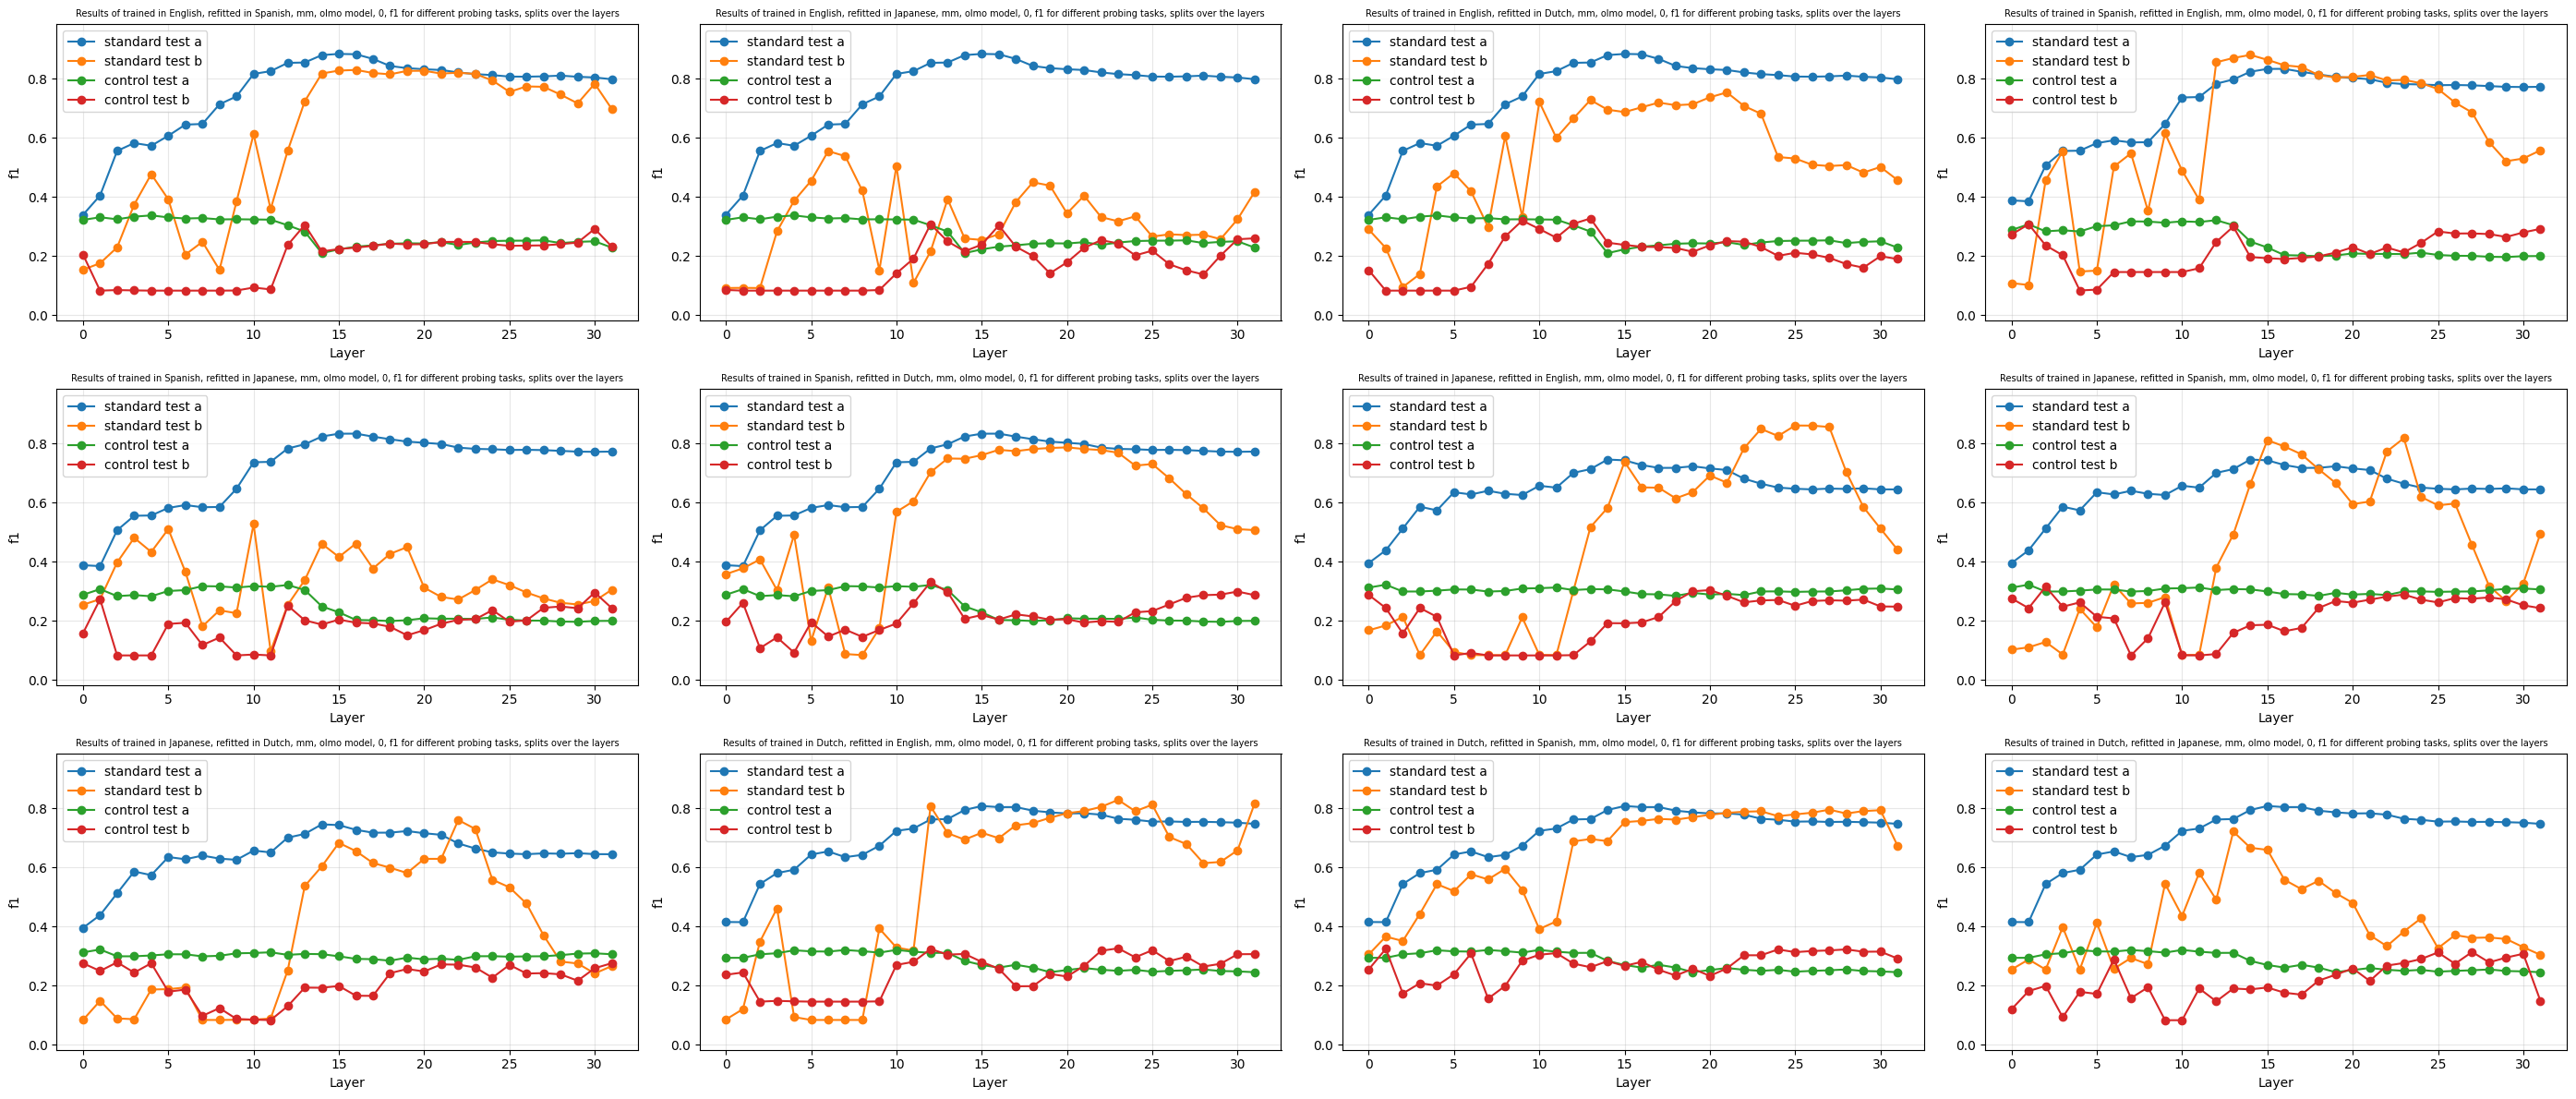

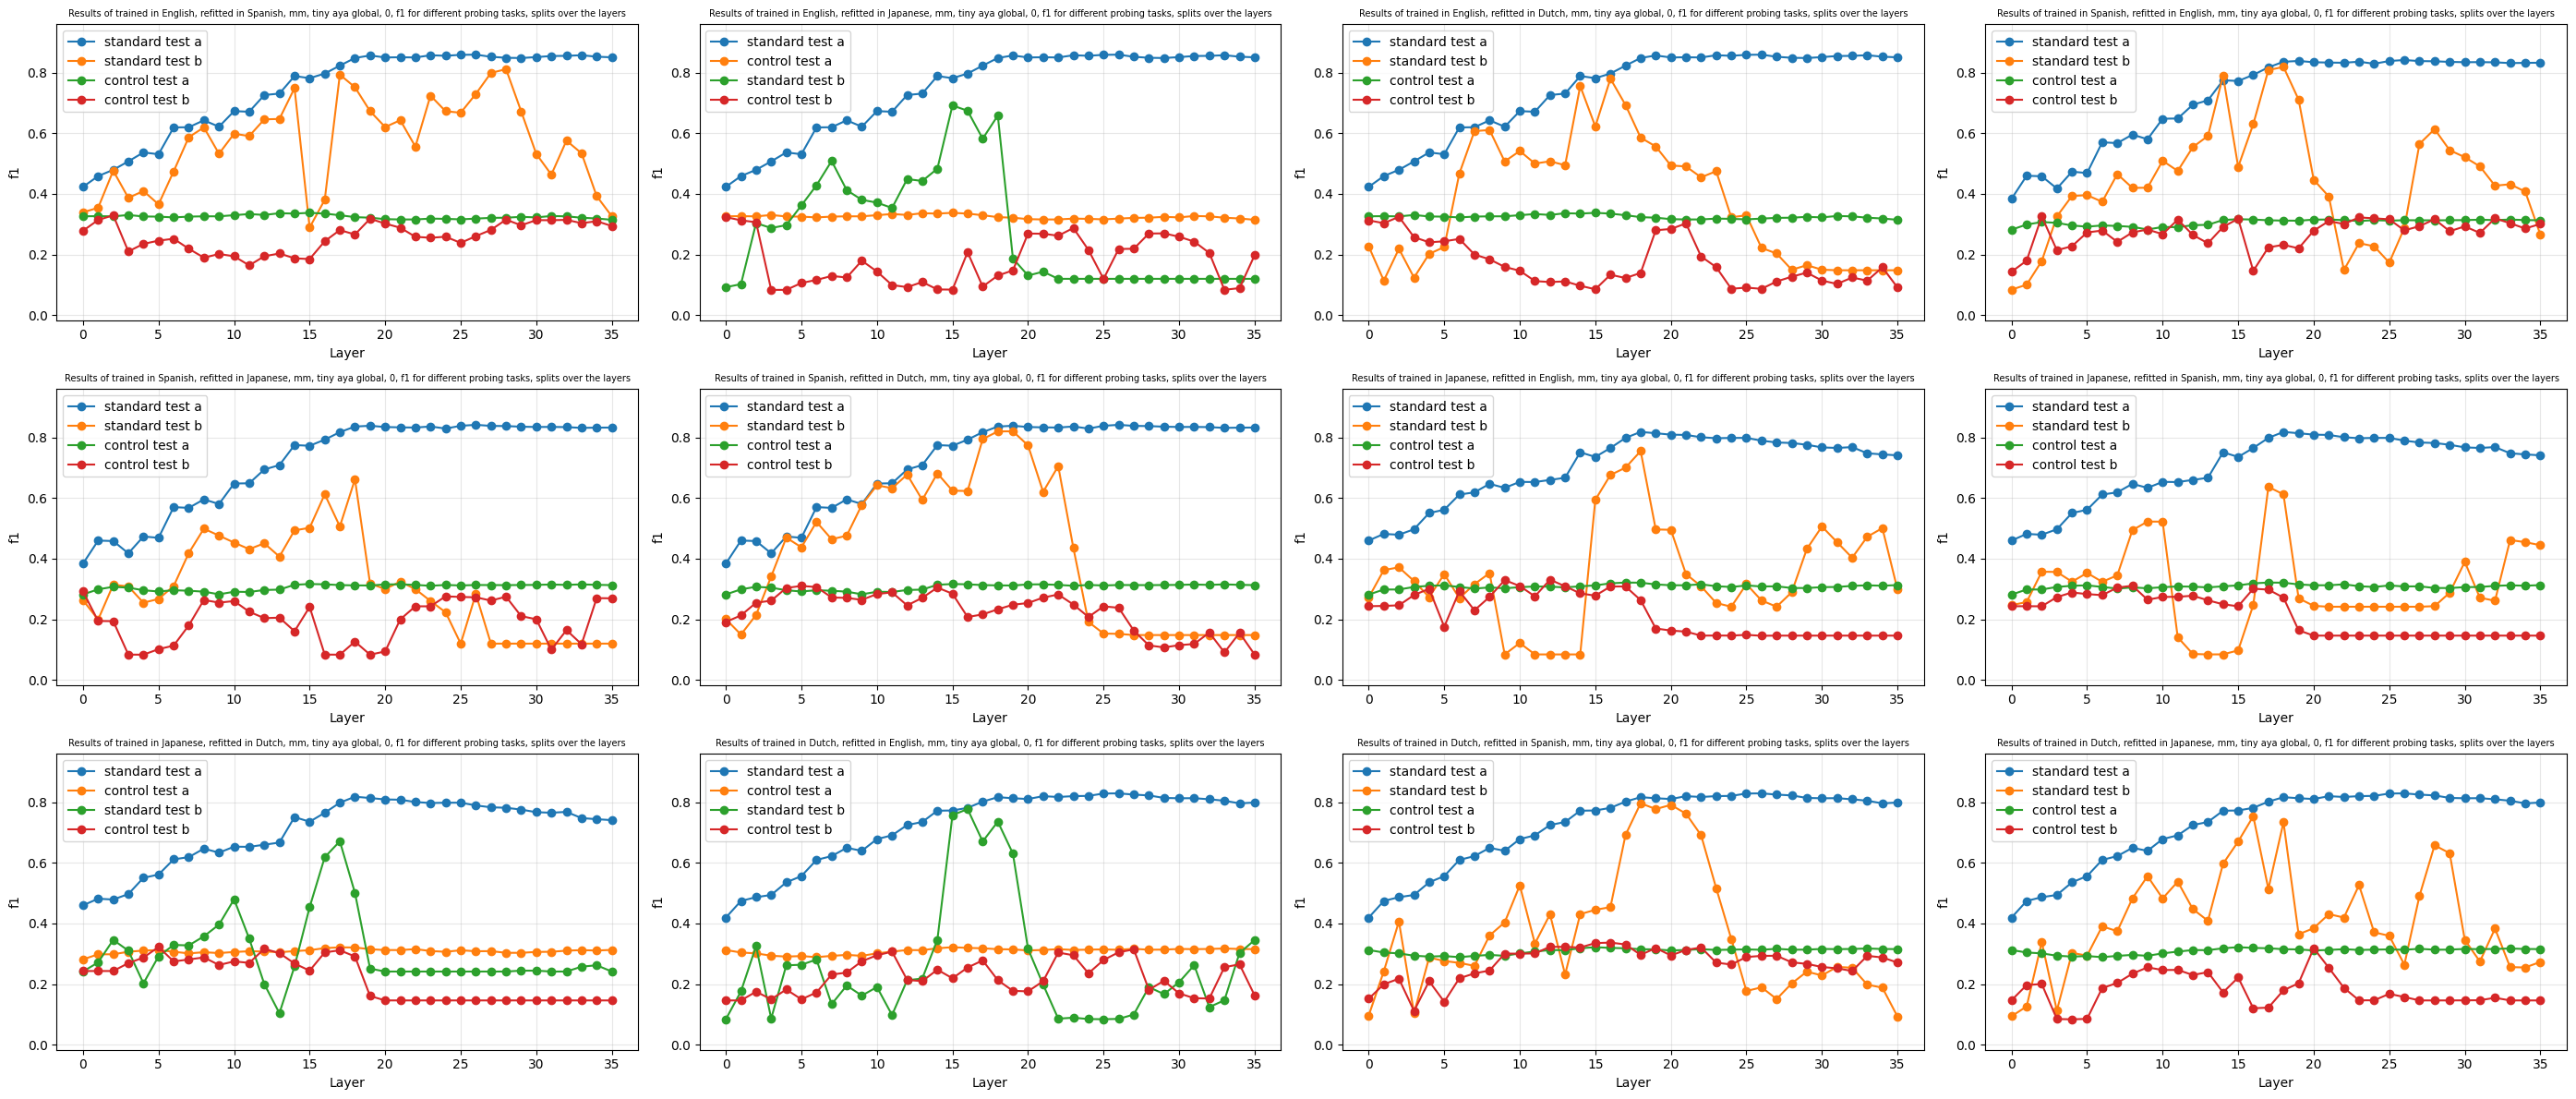

In [ ]:
language_pairs_as_strings_to_show: list[str] = language_pairs_as_strings
# language_pairs_as_strings_to_show = ["en→es"]

extra_iter_num_type = 3

match extra_iter_num_type:
    case 0:
        extra_iter_nums: list[int] = list(range(0, 5, 1))
    case 1:
        extra_iter_nums = [0, 1]
    case 2:
        extra_iter_nums = [0, 1000, 2000]
    case 3:
        extra_iter_nums = [0]

for extra_iter_num in extra_iter_nums:
    show_plots(2, 
            ["olmo_model"], 
            ["test_a", "test_b"],
            language_pairs_as_strings_to_show,
            ["standard", "control"], 
            [extra_iter_num],
            metric="f1",
            separate_chars_within_plot=["split", "probing_task"],
            save=True,
            filename=f"experiment_2_f1_per_layers_olmo_{extra_iter_num}_extra_iters",
            show=False,
            probe_type=probe_type,
            )
    show_plots(2, 
            ["tiny_aya_global"], 
            ["test_a", "test_b"],
            language_pairs_as_strings_to_show, 
            ["standard", "control"], 
            [extra_iter_num], 
            metric="f1",
            separate_chars_within_plot=["split", "probing_task"],
            save=True,
            filename=f"experiment_2_f1_per_layers_aya_{extra_iter_num}_extra_iters",
            show=False,
            probe_type=probe_type,
            )

Created line request:
["exp_result: [2, 'en→es', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→es', 'control', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'control', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'control', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'control', 'lr', 'olmo_

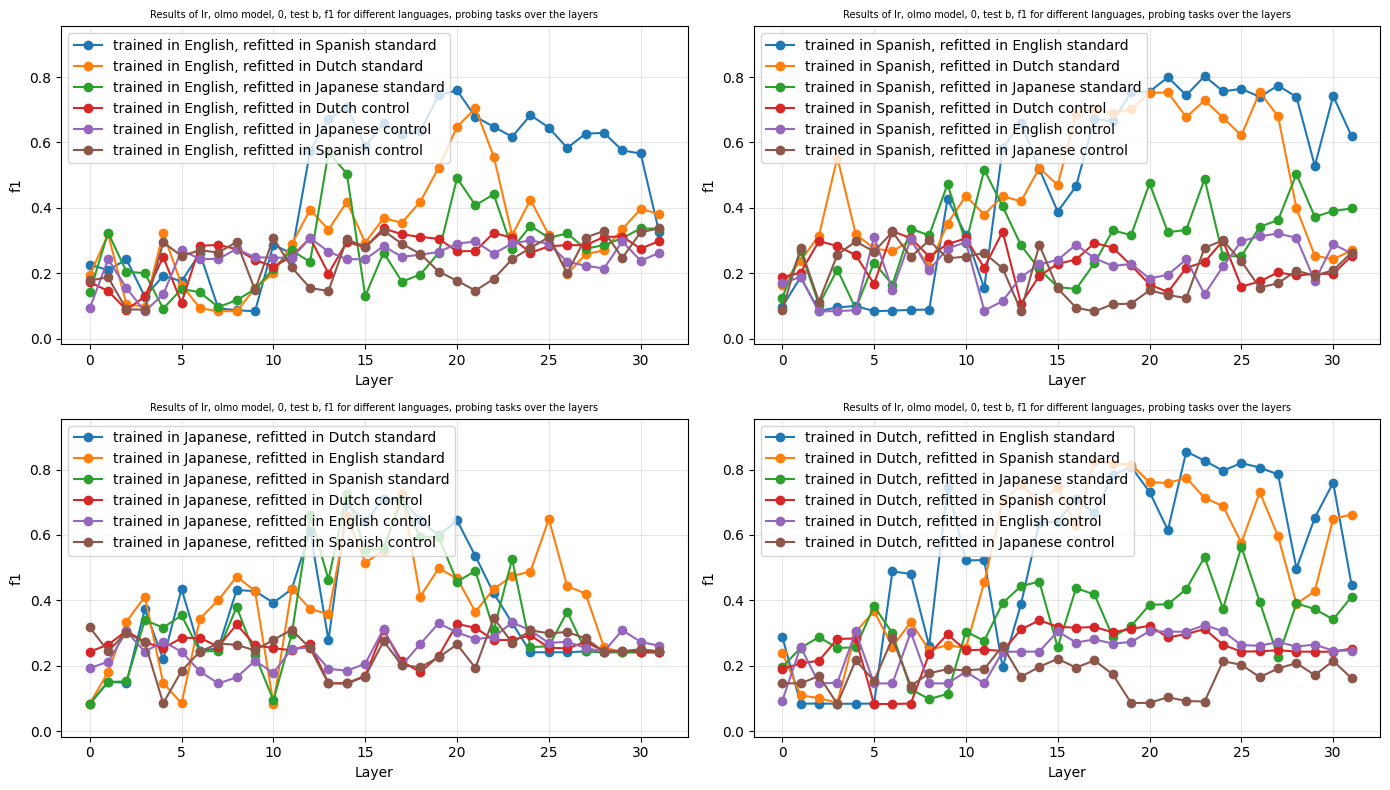

Created line request:
["exp_result: [2, 'en→es', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→es', 'control', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'control', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'control', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [

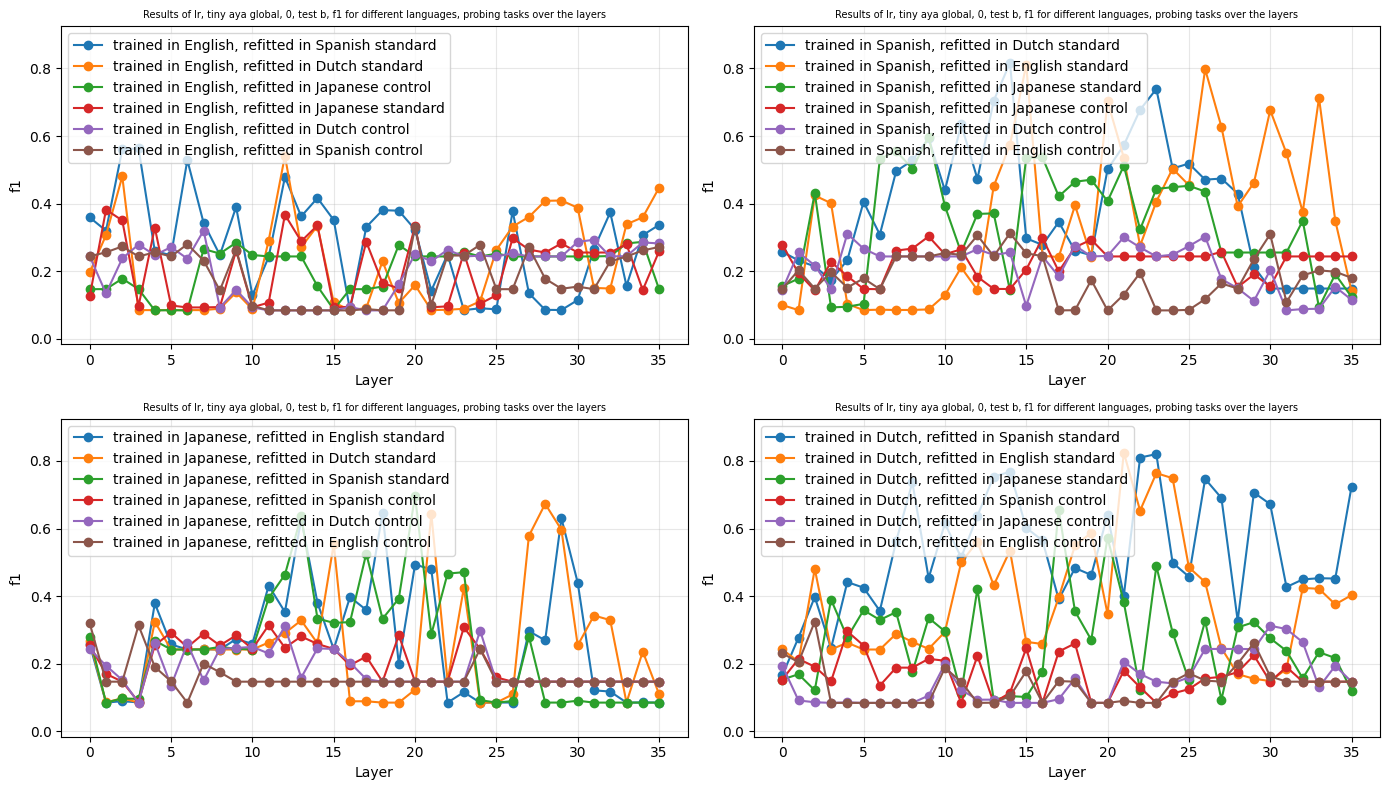

Created line request:
["exp_result: [2, 'en→es', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→es', 'control', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'control', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'control', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'control', 'lr', 'olmo_

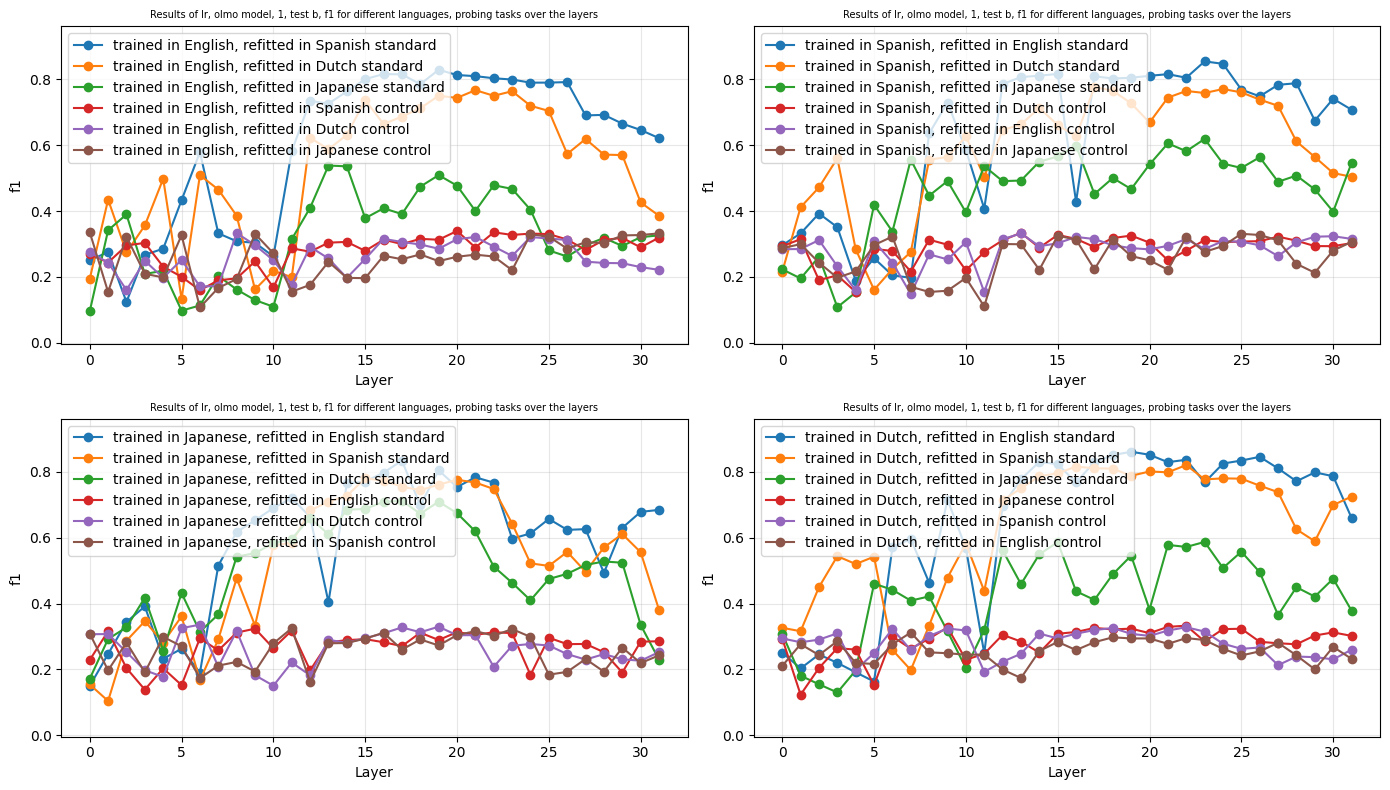

Created line request:
["exp_result: [2, 'en→es', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→es', 'control', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'control', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'control', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [

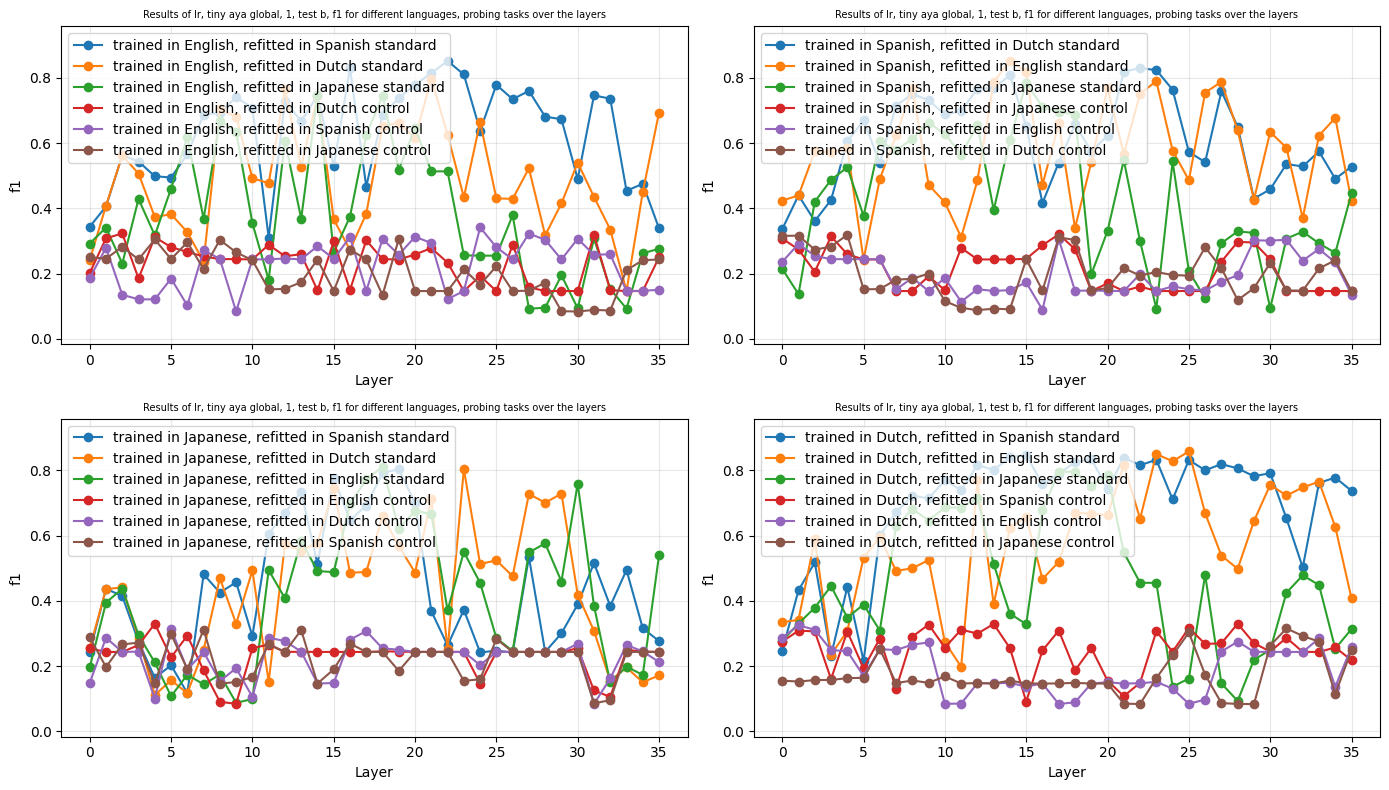

Created line request:
["exp_result: [2, 'en→es', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→es', 'control', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'control', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'control', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'standard', 'lr', 'olmo_model']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'control', 'lr', 'olmo_

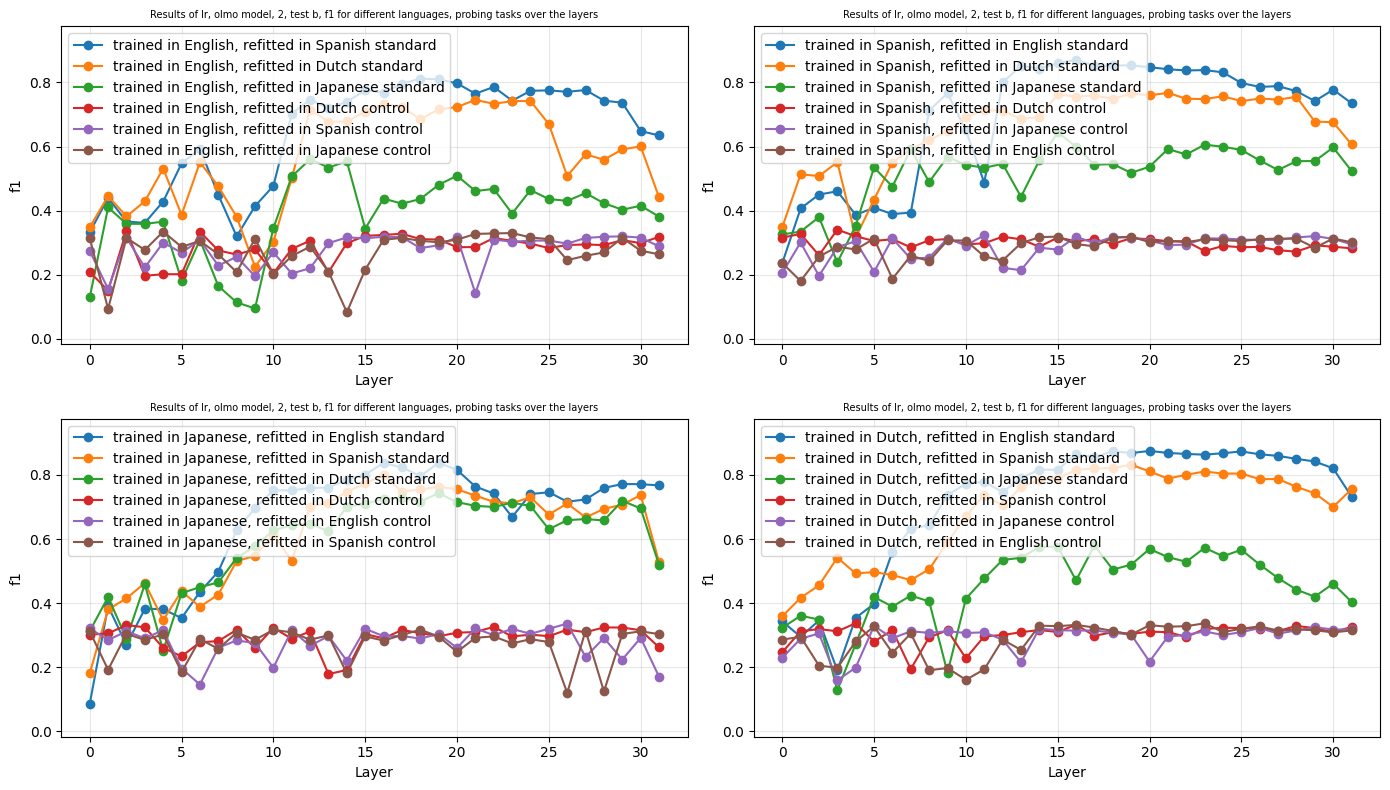

Created line request:
["exp_result: [2, 'en→es', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→es', 'control', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→jp', 'control', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'en→nl', 'control', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [2, 'es→en', 'standard', 'lr', 'tiny_aya_global']", 'split: test_b', 'class_id: ', 'class_name: all']
Created line request:
["exp_result: [

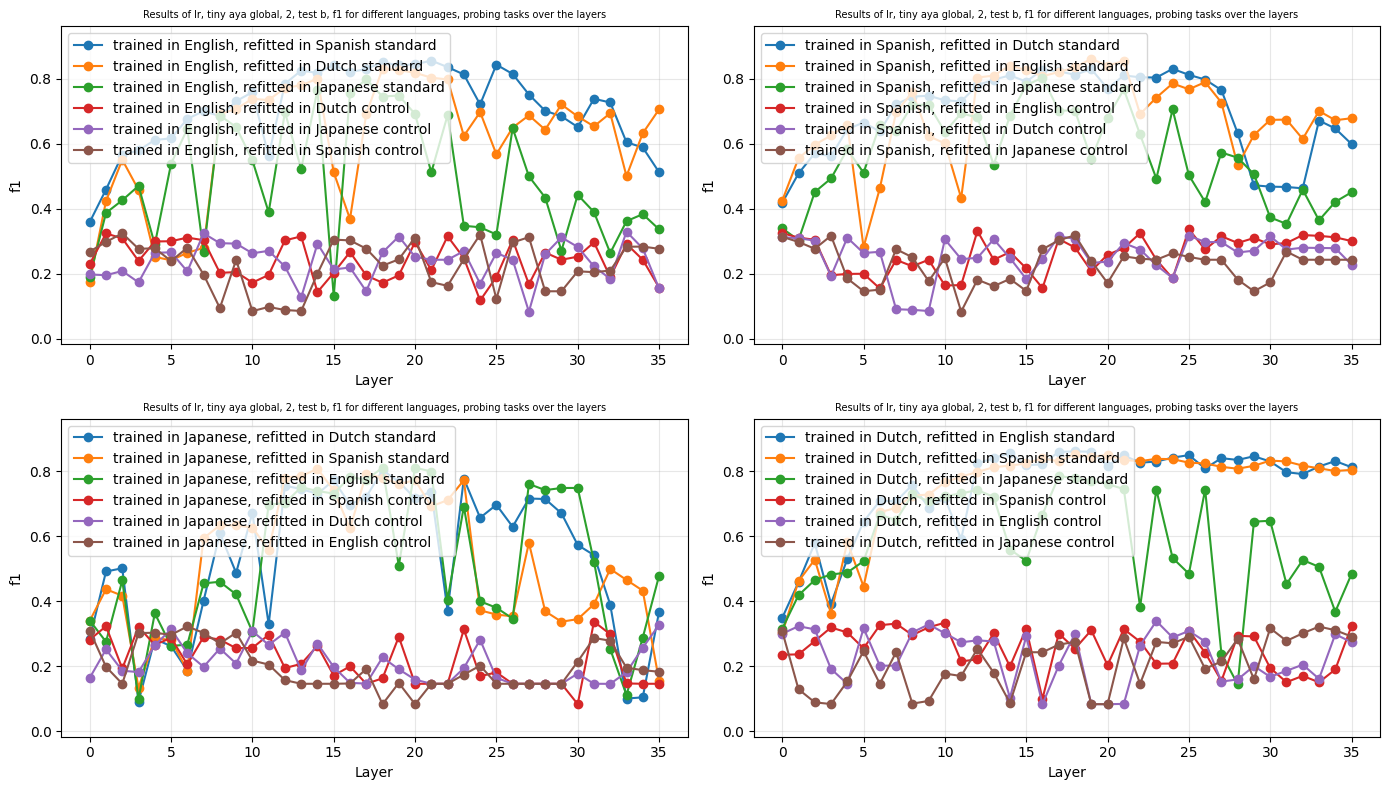

In [15]:
language_pairs_as_strings_to_show: list[str] = language_pairs_as_strings
# language_pairs_as_strings_to_show = ["en→es"]

extra_iter_num_type = 1

match extra_iter_num_type:
    case 0:
        extra_iter_nums: list[int] = list(range(0, 5, 1))
    case 1:
        extra_iter_nums = [0, 1, 2]
    case 2:
        extra_iter_nums = [0, 1000, 2000]
    case 3:
        extra_iter_nums = [0]

for extra_iter_num in extra_iter_nums:
    show_plots(2, 
            ["olmo_model"], 
            ["test_b"],
            language_pairs_as_strings_to_show,
            ["standard", "control"], 
            [extra_iter_num],
            metric="f1",
            separate_chars_within_plot=["language_b", "probing_task"],
            save=False,
            # filename=f"experiment_2_f1_per_layers_olmo_{extra_iter_num}_extra_iters",
            show=True,
            probe_type=probe_type,
            )
    show_plots(2, 
            ["tiny_aya_global"], 
            ["test_b"],
            language_pairs_as_strings_to_show, 
            ["standard", "control"], 
            [extra_iter_num], 
            metric="f1",
            separate_chars_within_plot=["language_b", "probing_task"],
            save=False,
            # filename=f"experiment_2_f1_per_layers_aya_{extra_iter_num}_extra_iters",
            show=True,
            probe_type=probe_type,
            )

In [ ]:
show_plots(2, 
           model_names, 
           ["test_b", "train_b"],
           ["en→es", "es→en"], 
           ["standard", "control"], 
           [0], 
           metric="f1",
           separate_chars_within_plot=["language", "probing_task"],
           probe_type=probe_type
           )

In [ ]:
show_plots(2, 
           model_names, 
           ["test"],
           language_pairs_as_strings, 
           ["standard", "control"], 
           list(range(0, num_refits * iterations_per_refit, iterations_per_refit)), 
           metric="f1",
           separate_chars_within_plot=["extra_iter_num"],
           probe_type=probe_type
           )

In [ ]:
extra_iter_nums: list[int] = [0, 1, 2, 9]
for extra_iter_num in extra_iter_nums:
    show_plots(2, 
            model_names, 
            ["test"],
            language_pairs_as_strings, 
            ["standard", "control"], 
            [extra_iter_num], 
            metric="f1",
            separate_chars_within_plot=["language"],
            save=True,
            filename=f"experiment2_accuracy_{extra_iter_num}_extra_iters",
            y_axis_range=(0.2, 1.0),
            probe_type=probe_type,
            )

In [ ]:
# Get list of plots showing some arbitrary metric
metric = "f1"
show_plots(2, 
           ["olmo_model", "tiny_aya_global"], 
           ["test"], 
           language_pairs_as_strings, 
           ["standard", "control"], 
           [3],
           metric=metric,
           y_axis_range=(0.0, 1.0),
           probe_type=probe_type,
           )

In [ ]:
# for model_name in model_names:
#     for split in ["test"]:
#         for language in languages:
#             for probing_task in probing_tasks:
#                 exp_result: ExperimentResult = ExperimentResult.get_from_file(
#                     2, language, probing_task, probe_type, model_name
#                 )

#                 for layer_num in range(exp_result.get_num_layers()):
#                     plot_confusion_matrix(exp_result, split, layer_num)

for probing_task in ["standard", "control"]:
    exp_result: ExperimentResult = ExperimentResult.get_from_file(2, "en", probing_task, probe_type, "olmo_model")

    for layer_num in range(exp_result.get_num_layers()):
        plot_confusion_matrix(exp_result, "test", layer_num)

# Experiment 3

Load important variables

In [ ]:
from experiment_3 import run_experiment_3

model_names: list[str] = MODEL_NAMES
languages: list[str] = LANGUAGES

custom = False
if custom:
    model_names = ["olmo_model"]
    languages = ["en"]
    print(f"Using custom configuration")

ic(custom, model_names, languages)

In [ ]:
run_experiment_3(languages, model_names)
# run_experiment_3(["nl"], ["olmo_model"])
# run_experiment_3(["es", "nl"], ["tiny_aya_global"])

In [ ]:
from pandas.core.frame import DataFrame


class E3DataframeCreator:
    def __init__(self, model_name:str, languages:list[str], include_unk:bool=False, include_control:bool=False, include_strict=False) -> None:
        self.model_name: str = model_name
        self.languages: list[str] = languages
        self.include_unk: bool = include_unk
        self.include_control: bool = include_control
        self.include_strict: bool = include_strict

    def create_dataframe(self) -> DataFrame:
        self.data: dict[str, Any] = {}

        self.add_row("f1")
        if self.include_unk: 
            self.add_row("f1_including_unk")
        self.add_row("per_class_f1", cls=0)
        self.add_row("per_class_f1", cls=1)
        self.add_row("per_class_f1", cls=2)
        self.add_row("unk_count")

        df: DataFrame = pd.DataFrame.from_dict(self.data, orient='index')
        
        df = df.astype(object) 
        
        df.loc['unk count'] = df.loc['unk count'].astype(int)

        return df

    def add_value(self, metric, cls, language, control=False, strict=False):
        if control:
            probing_task = "control"
            if self.include_strict: raise ValueError("control and strict cannot both be true")
        elif strict:
            probing_task = "strict"
        else:
            probing_task = "standard"
        
        exp_result: ExperimentResult = ExperimentResult.get_from_file(3, language, probing_task, "model_pred", self.model_name)
        metric_values = exp_result.get_metric("test", metric)

        if len(metric_values) != 1:
            raise ValueError("picked metric that has more than one value stored")
        metric_value = metric_values[0]

        if cls is not None:
            metric_value = metric_value[str(cls)]
        
        print(metric_value)
        
        return metric_value

    def add_row(self, metric:str, cls:None|int=None) -> None:
        if cls is None:
            row_name: str = metric
        else:
            if "per_class" not in metric:
                raise AttributeError(f"cls cannot be None for metric {metric}, since it is not per-class")
            row_name = f"{metric} for {REVERSE_LABEL_MAP[cls]}"

        row_name = row_name.replace("_", " ")
        self.data[row_name] = {}

        for language in languages:
            self.data[row_name][language] = self.add_value(metric, cls, language)
        
            if self.include_control:
                self.data[row_name][f"{language}_control"] = self.add_value(metric, cls, language, control=True)

            if self.include_strict:
                self.data[row_name][f"{language}_strict"] = self.add_value(metric, cls, language, strict=True)

In [ ]:
dataframe_creator_olmo = E3DataframeCreator("olmo_model", languages, include_strict=True)
df_e3_olmo: DataFrame = dataframe_creator_olmo.create_dataframe()
print(df_e3_olmo.to_latex(float_format="%.2f"))
df_e3_olmo

In [ ]:
dataframe_creator_aya = E3DataframeCreator("tiny_aya_global", languages, include_strict=True)
df_e3_aya: DataFrame = dataframe_creator_aya.create_dataframe()
print(df_e3_aya.to_latex(float_format="%.2f"))
df_e3_aya

In [ ]:
for model_name in model_names:
    for language in languages:
        exp_result: ExperimentResult = ExperimentResult.get_from_file(3, language, "standard", "model_pred", model_name)
        plot_confusion_matrix(exp_result, "test", include_unknown=True)